# Processing time courses.

In [1]:
from pathlib import Path
import numpy as np
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
from pipeline_time_courses import (
    compute_autocorrelation_for_dataset,
    compute_cross_correlation_for_dataset,
    analyze_crosscorr,
    analyze_dual_channel_time_courses,
    run_simulation_and_generate_data,
    plot_dual_channel_kymograph,
)


In [ ]:
#data_folder = Path('/Users/nzlab-la/Desktop/processing_GFPsf')
data_folder = Path('/Users/nzlab-la/Desktop/processing_GFPuv')
#data_folder = Path('/Users/nzlab-la/Desktop/processing_GFP1X')
results_folder = data_folder.joinpath('processing')
results_folder.mkdir(exist_ok=True) 

In [3]:
# Parameters
step_size_in_sec = 5
start_lag = 1
selected_field = 'spot_int_ch_' #'spot_int_ch_' #'spot_int_ch_'  # spot_int_ch_0, psf_amplitude_ch_, snr_ch_, total_spot_int_ch_
min_percentage_data_in_trajectory = 0.2
max_missing_frames = 3
downsample = False
downsampling_factor = 3
control_spots_mode = False
use_global_mean = False
dataset_name = 'cof'
y_axes_min_max_list_values =  [-0.02, 0.04]
x_axes_min_max_list_values = [-10, 1000]
max_lag = None#360
if control_spots_mode:
    y_axes_min_max_list_values = None # [-20, 20]
remove_outliers = True
MAD_THRESHOLD_FACTOR = 6 # 6 was working well for the control spots. 
multi_tau=True
multi_tau_raw_points = 40
multi_tau_bins_per_stage = 20
min_snr = 1 # 1 #0.5
smooth_window = 1
correct_baseline = True

color_green = (0.0, 1.0, 0.0)  # No Red, Full Green, No Blue
color_magenta = (1.0, 0.0, 1.0)  # Full Red, No Green, Full Blue


In [ ]:
# simulation mode
simulation_mode = False
# Load the sequences.
if simulation_mode:
    gene_sequence_path = current_dir.parents[1].joinpath('data','gene_sequences','pRS032 (pUB-RBsmHA-4xmGFPuvq-2xmCherryq-24xMS2).dna')
    SSA_HA, SSA_GFP = run_simulation_and_generate_data(gene_sequence_path, ki=0.08, ke_global=6, step_size_in_sec=step_size_in_sec, folding_delay=7, t_max = 360*5,)
else:
    SSA_HA, SSA_GFP = None, None

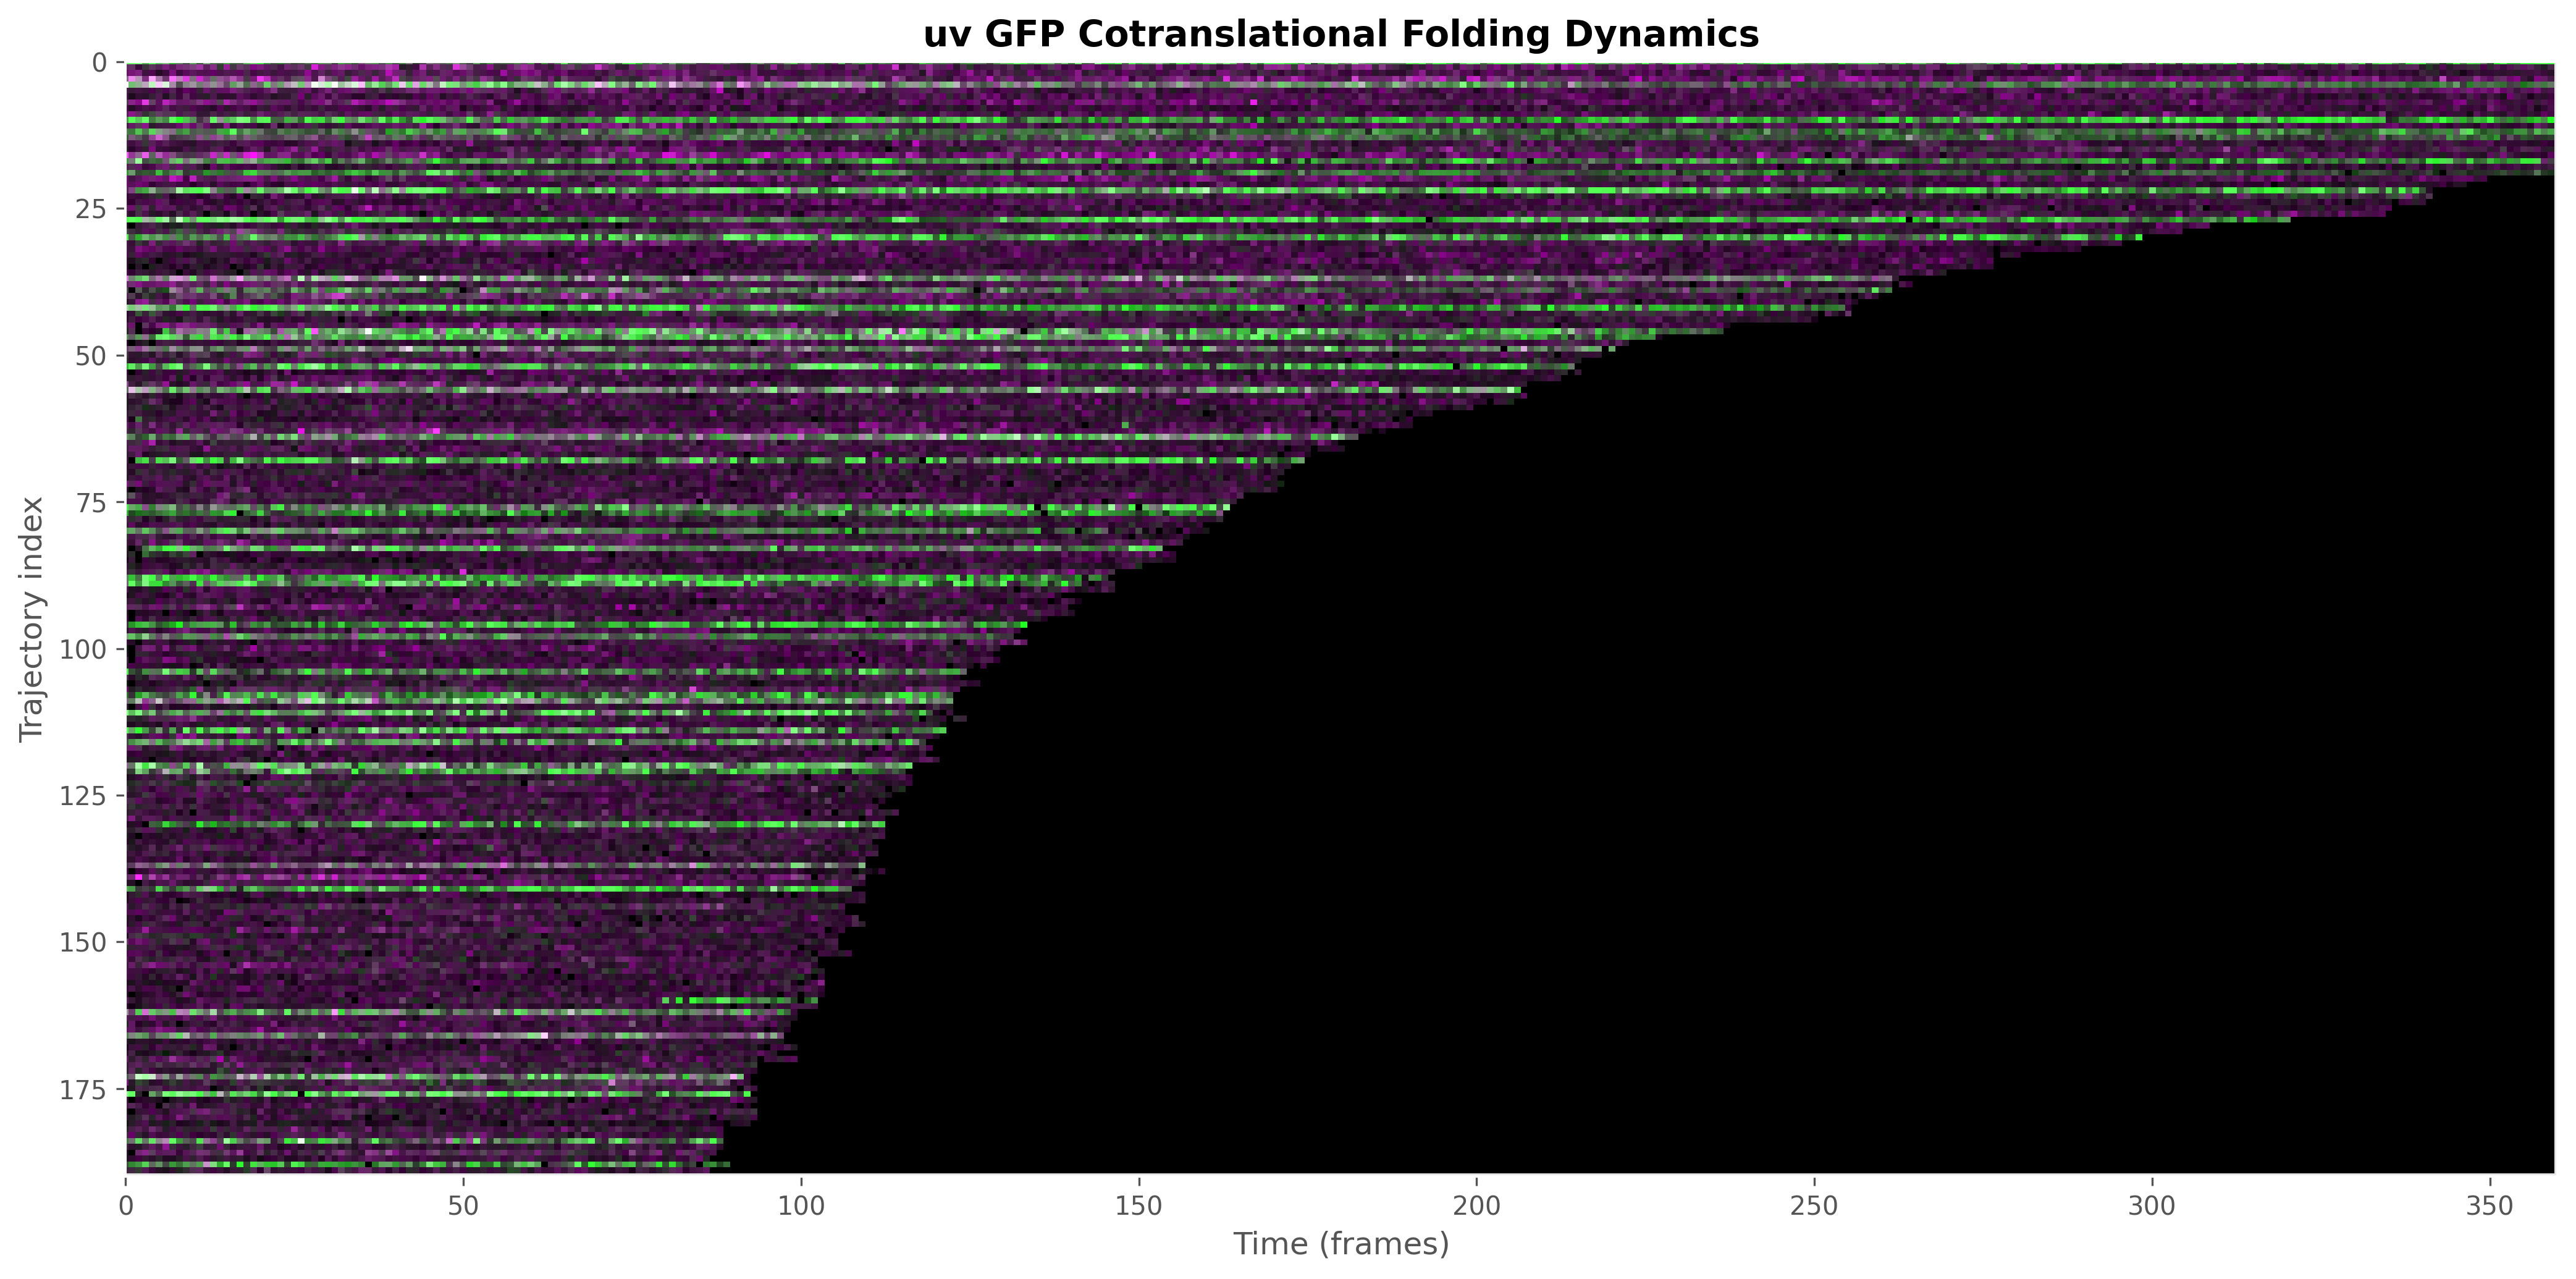

In [12]:
if simulation_mode:
    img, primary, secondary = plot_dual_channel_kymograph(
        dataset='cof',
        selected_field='snr_ch_',
        primary_channel=1,
        secondary_channel=0,
        normalize="per_trace_percentile",
        p_lo=1,
        p_hi=99,
        sort_by_data_density=True,
        nan_color=(0.0, 0.0, 0.0),  # Black for missing data
        title="Simulated Cotranslational Folding Dynamics",
        figsize=(12, 12),
        dpi=300,
        #save_path=results_folder / 'kymograph_simulation.png',
        show=True,
        verbose=False,
        simulation_mode=True,
        SSA_data_1=SSA_HA/np.max(SSA_HA),
        SSA_data_2=SSA_GFP/np.max(SSA_GFP),
        shift_data= True,
        use_binarization=True, 
        binarization_threshold=0.5,  
        channel_colors=['r', 'g'],
        #channel_colors=[(0.0, 1.0, 0.5), (1.0, 0.5, 0.0)],  # Custom blend
    )
else:
    img_exp, primary_exp, secondary_exp = plot_dual_channel_kymograph(
    dataset='cof',
    data_folder=data_folder,
    results_folder=results_folder,
    selected_field='snr_ch_',
    primary_channel=1,
    secondary_channel=0,
    min_percentage_data_in_trajectory=0.2,
    max_missing_frames=3,
    min_snr=0,
    smooth_window=1,
    normalize= None, #"per_trace_percentile", #"per_trace_percentile",
    p_lo=1,
    p_hi=99,
    sort_by_data_density=True,
    nan_color=(0.0, 0.0, 0.0),
    title="uv GFP Cotranslational Folding Dynamics",
    figsize=(14, 7),
    dpi=300,
    #channel_colors=['r', 'g'],
    channel_colors=[color_magenta, color_green,],  # Custom blend
    #save_path=results_folder / 'kymograph_experimental.png',
    show=True,
    verbose=False,
    simulation_mode=False,
    shift_data= True,
    use_binarization=False, 
    binarization_threshold=0.3,  
    max_traces_to_plot=190,
)